In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
import pickle
from sklearn.metrics import classification_report
from skopt.space import Real, Integer

from lightgbm import LGBMClassifier, early_stopping
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

from pathlib import Path
root_dir = Path.cwd().parent
sys.path.append(str(root_dir))
from utils.helpers import set_global_settings, find_best_params

In [2]:
RANDOM_STATE = int(os.getenv("RANDOM_STATE", 100))

# Apply global settings
set_global_settings()

In [3]:
target_variable = 'loan_status'

parent_dir = root_dir / "datasets"

train_df = pd.read_csv(parent_dir / "sampled_train_data.csv")
val_df = pd.read_csv(parent_dir / "validation_set.csv")
test_df = pd.read_csv(parent_dir / "test_set.csv")

X_train = train_df.drop(columns=[target_variable])
y_train = train_df[target_variable]

X_val = val_df.drop(columns=[target_variable])
y_val = val_df[target_variable]

X_test = test_df.drop(columns=[target_variable])
y_test = test_df[target_variable]

In [4]:
xgb_clf = XGBClassifier(eval_metric='logloss', verbosity=0, random_state=RANDOM_STATE)

search_space_xgb = {
    'learning_rate': Real(1e-3, 0.1, prior='log-uniform'),
    'n_estimators': Integer(100, 500),
    'max_depth': Integer(3, 12),
    'min_child_weight': Integer(1, 10),
    'subsample': Real(0.5, 1.0),
    'colsample_bytree': Real(0.5, 1.0),
    'gamma': Real(0, 5),
    'reg_alpha': Real(1e-3, 10, prior='log-uniform'),
    'reg_lambda': Real(1e-3, 10, prior='log-uniform'),
    'scale_pos_weight': Real(1, 10, prior='log-uniform')
}

opt_xgb_clf = find_best_params(
    xgb_clf,
    search_space_xgb,
    X_train,
    y_train,
    random_state=RANDOM_STATE,
    metric='f1_weighted'
    )

opt_xgb_clf.fit(X_train, y_train)
y_pred_xgb = opt_xgb_clf.predict(X_val)

Best Parameters:
{'colsample_bytree': 0.5,
 'gamma': 0.5127709181028001,
 'learning_rate': 0.061237499948266126,
 'max_depth': 12,
 'min_child_weight': 1,
 'n_estimators': 500,
 'reg_alpha': 0.001,
 'reg_lambda': 0.001,
 'scale_pos_weight': 1.0,
 'subsample': 0.7117941602270779}


In [5]:
# Define model
lgb_clf = LGBMClassifier(verbose=-1, objective='binary', random_state=RANDOM_STATE)

# Define search space
search_space_lgb = {
    'learning_rate': Real(1e-3, 0.1, prior='log-uniform'),
    'num_leaves': Integer(20, 150),
    'max_depth': Integer(3, 12),
    'n_estimators': Integer(100, 500),
    'min_split_gain': Real(0.0, 0.5),
    'min_child_weight': Real(1e-3, 10, prior='log-uniform'),
    'min_child_samples': Integer(10, 200),
    'subsample': Real(0.4, 1.0),
    'subsample_freq': Integer(1, 7),
    'colsample_bytree': Real(0.4, 1.0),
    'reg_alpha': Real(1e-3, 10, prior='log-uniform'),
    'reg_lambda': Real(1e-3, 10, prior='log-uniform')
}

# Get best estimator using Bayesian Optimization
opt_lgb_clf = find_best_params(
    lgb_clf, 
    search_space_lgb, 
    X_train,
    y_train,
    random_state=RANDOM_STATE, 
    metric='f1_weighted'
    )

opt_lgb_clf.fit(X_train, y_train)
y_pred = opt_lgb_clf.predict(X_val)

Best Parameters:
{'colsample_bytree': 1.0,
 'learning_rate': 0.1,
 'max_depth': 9,
 'min_child_samples': 10,
 'min_child_weight': 0.001,
 'min_split_gain': 0.0,
 'n_estimators': 500,
 'num_leaves': 150,
 'reg_alpha': 0.23120958677821418,
 'reg_lambda': 0.001,
 'subsample': 0.7415733664393169,
 'subsample_freq': 3}


In [6]:
rf_clf = RandomForestClassifier(min_samples_leaf=50, max_features='sqrt', bootstrap=True, verbose=0, random_state=RANDOM_STATE)

search_space_rf = {
    'n_estimators': Integer(100, 500),
    'max_depth': Integer(3, 12),
    'min_samples_split': Integer(2, 20),
    'max_leaf_nodes': Integer(10, 100),
    'min_impurity_decrease': Real(0.0, 0.5),
    'max_samples': Real(0.5, 1.0),
    'ccp_alpha': Real(1e-3, 10, prior='log-uniform')
}

opt_rf_clf = find_best_params(
    rf_clf,
    search_space_rf,
    X_train,
    y_train,
    random_state=RANDOM_STATE,
    metric='f1_weighted'
    )

opt_rf_clf.fit(X_train, y_train)
y_pred_rf = opt_rf_clf.predict(X_val)

Best Parameters:
{'ccp_alpha': 0.001,
 'max_depth': 12,
 'max_leaf_nodes': 50,
 'max_samples': 0.6614413166177416,
 'min_impurity_decrease': 0.0,
 'min_samples_split': 2,
 'n_estimators': 179}


In [7]:
bg_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(ccp_alpha=0.01, random_state=RANDOM_STATE), 
    verbose=0, 
    bootstrap=True, 
    bootstrap_features=True, 
    random_state=RANDOM_STATE
    )

search_space_bg = {
    # Bagging-level hyperparameters
    'n_estimators': Integer(100, 500),
    'max_samples': Real(0.5, 1.0),
    'max_features': Real(0.5, 1.0),

    # DecisionTreeClassifier (base estimator) hyperparameters
    'estimator__max_depth': Integer(3, 15),
    'estimator__min_samples_split': Integer(2, 20),
    'estimator__min_samples_leaf': Integer(1, 50)
}

opt_bg_clf = find_best_params(
    bg_clf,
    search_space_bg,
    X_train,
    y_train,
    random_state=RANDOM_STATE,
    metric='f1_weighted'
    )

opt_bg_clf.fit(X_train, y_train)
y_pred_bg = opt_bg_clf.predict(X_val)

Best Parameters:
{'estimator__max_depth': 8,
 'estimator__min_samples_leaf': 28,
 'estimator__min_samples_split': 16,
 'max_features': 0.8520894661713535,
 'max_samples': 0.6663152282118947,
 'n_estimators': 176}


In [8]:
et_clf = ExtraTreesClassifier(verbose=0, bootstrap=True, random_state=RANDOM_STATE)

search_space_et = {
    'n_estimators': Integer(100, 500),
    'max_depth': Integer(3, 12),
    'min_samples_leaf': Integer(1, 20),
    'min_samples_split': Integer(2, 20),
    'max_leaf_nodes': Integer(10, 100),
    'min_impurity_decrease': Real(0.0, 0.5),
    'max_samples': Real(0.5, 1.0)
}

opt_et_clf = find_best_params(
    et_clf,
    search_space_et,
    X_train,
    y_train,
    random_state=RANDOM_STATE,
    metric='f1_weighted'
    )

opt_et_clf.fit(X_train, y_train)
y_pred_et = opt_et_clf.predict(X_val)

Best Parameters:
{'max_depth': 12,
 'max_leaf_nodes': 100,
 'max_samples': 1.0,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 20,
 'n_estimators': 500}


In [9]:
# Generate classification reports for all models with output_dict=True
reports = {
    'LightGBM': classification_report(y_val, opt_lgb_clf.predict(X_val), output_dict=True),
    'XGBoost': classification_report(y_val, opt_xgb_clf.predict(X_val), output_dict=True),
    'RandomForest': classification_report(y_val, opt_rf_clf.predict(X_val), output_dict=True),
    'ExtraTrees': classification_report(y_val, opt_et_clf.predict(X_val), output_dict=True),
    'Bagging': classification_report(y_val, opt_bg_clf.predict(X_val), output_dict=True),
}

average_type = 'weighted avg'

# Extract weighted metrics and create dataframe
metrics_df = pd.DataFrame({
    'Model': list(reports.keys()),
    'Balanced Accuracy': [reports[model]['accuracy'] for model in reports.keys()],
    'Weighted Precision': [reports[model][average_type]['precision'] for model in reports.keys()],
    'Weighted Recall': [reports[model][average_type]['recall'] for model in reports.keys()],
    'Weighted F1-Score': [reports[model][average_type]['f1-score'] for model in reports.keys()],
})

metrics_df.sort_values(by=['Weighted F1-Score', 'Balanced Accuracy', 'Weighted Recall', 'Weighted Precision'], ascending=False)

,Model,Balanced Accuracy,Weighted Precision,Weighted Recall,Weighted F1-Score
1,XGBoost,0.92,0.92,0.92,0.92
0,LightGBM,0.92,0.92,0.92,0.92
2,RandomForest,0.87,0.90,0.87,0.88
3,ExtraTrees,0.84,0.89,0.84,0.85
4,Bagging,0.84,0.88,0.84,0.85


Both `XGBClassifier` and `LGBMClassifier` have same metrics so we choose `LGBMClassifier` as it is faster and takes less time to train.

In [10]:
# Train best model
best_model = LGBMClassifier(**opt_lgb_clf.get_params())
best_model.fit(
    X_train, 
    y_train, 
    eval_set=[(X_val, y_val)], 
    eval_metric='logloss',
    callbacks=[early_stopping(stopping_rounds=50)]
)

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[192]	valid_0's binary_logloss: 0.174205


,boosting_type,'gbdt'
,num_leaves,150
,max_depth,9
,learning_rate,0.1
,n_estimators,500
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,10


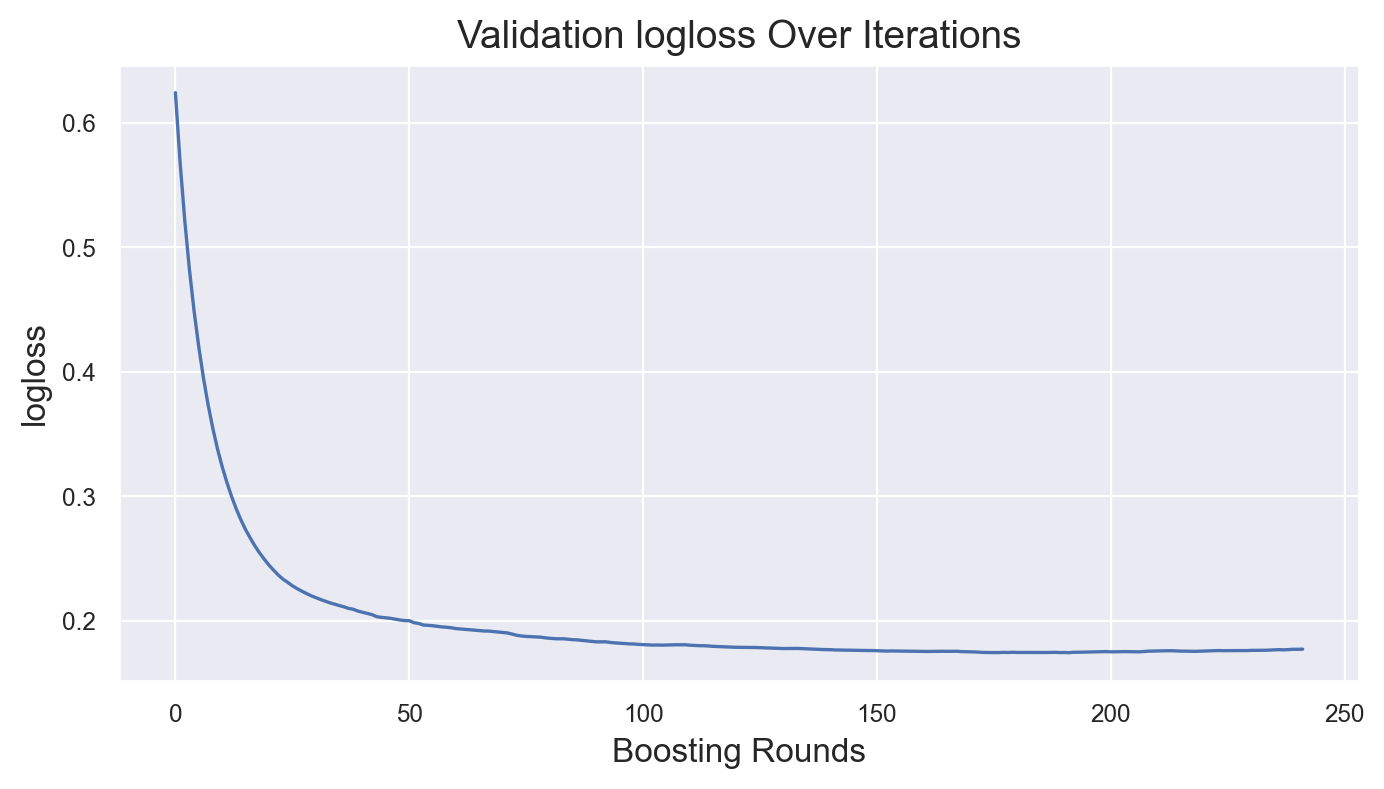

In [11]:
series = pd.Series(list(best_model.evals_result_['valid_0'].values())[0])

plt.figure(figsize=(8, 4))
plt.plot(series.index, series.values)
plt.xlabel("Boosting Rounds")
plt.ylabel("logloss")
plt.title("Validation logloss Over Iterations")
plt.show()

In [12]:
# Evaluate best model on test set
y_test_pred = best_model.predict(X_test)
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.96      0.95      0.95      3413
           1       0.83      0.85      0.84       978

    accuracy                           0.93      4391
   macro avg       0.89      0.90      0.89      4391
weighted avg       0.93      0.93      0.93      4391



In [13]:
# Save the trained model
model_save_path = root_dir / "models" / "best_model.pkl"
with open(model_save_path, 'wb') as f:
    pickle.dump(best_model, f)